Minimum:3.00
Mean:49.18
Median:49.50
Mode:50.00
Maximum:97.00



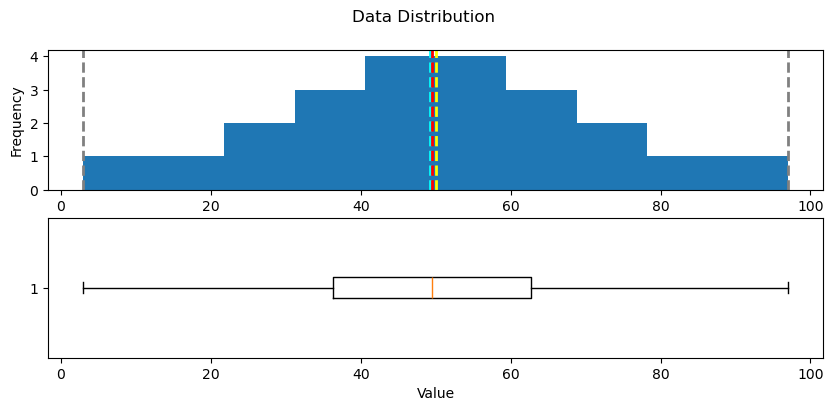

In [ ]:
import pandas as pd
import urllib.request
from matplotlib import pyplot as plt

# 1. Load the data (Windows-friendly)
url = "https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/grades.csv"
filename = "grades.csv"
urllib.request.urlretrieve(url, filename)

df_students = pd.read_csv('grades.csv', delimiter=',', header='infer')

# 2. Clean data and add the 'Pass' column
df_students = df_students.dropna(axis=0, how='any')
passes = pd.Series(df_students['Grade'] >= 60)
df_students = pd.concat([df_students, passes.rename("Pass")], axis=1)
  
# 3. Create the show_distribution function
def show_distribution(var_data):
    # Get statistics
    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mod_val = var_data.mode()[0]

    print(f'Minimum:{min_val:.2f}\nMean:{mean_val:.2f}\nMedian:{med_val:.2f}\nMode:{mod_val:.2f}\nMaximum:{max_val:.2f}\n')

    # Create a figure for 2 subplots (1 row, 2 columns)
    fig, ax = plt.subplots(2, 1, figsize = (10,4))

    # Plot the histogram   
    ax[0].hist(var_data)
    ax[0].set_ylabel('Frequency')


    # Add lines for the statistics
    ax[0].axvline(x=min_val, color = 'gray', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

    # Plot the boxplot   
    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('Value')

    # Add a title to the Figure
    fig.suptitle('Data Distribution')

    # Show the figure
    plt.show()

# 4. Call the function for the Grade column
col = df_students['Grade']
show_distribution(col)

Minimum:1.00
Mean:10.52
Median:10.00
Mode:9.00
Maximum:16.00



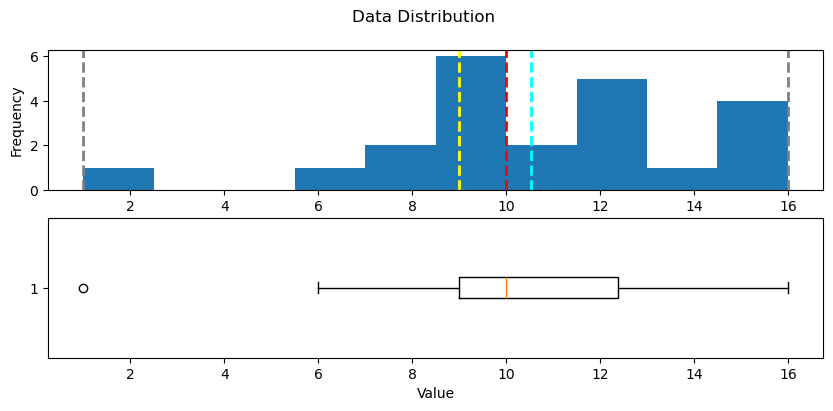

In [18]:
show_distribution(df_students.StudyHours)

Minimum:6.00
Mean:10.98
Median:10.00
Mode:9.00
Maximum:16.00



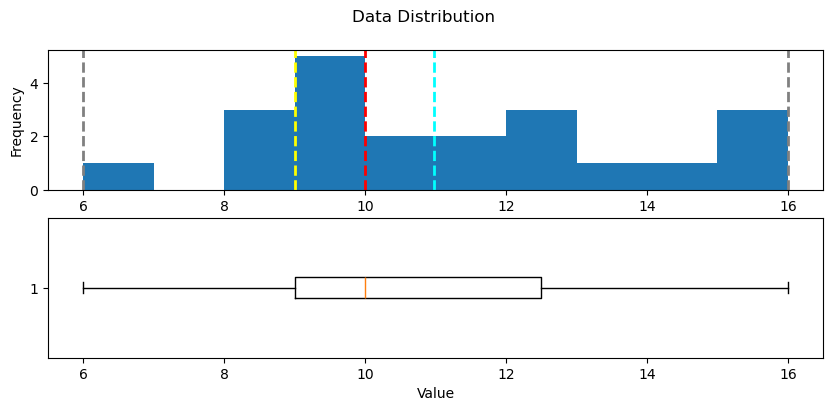

In [19]:
col = df_students[df_students.StudyHours>1]['StudyHours']
show_distribution(col)

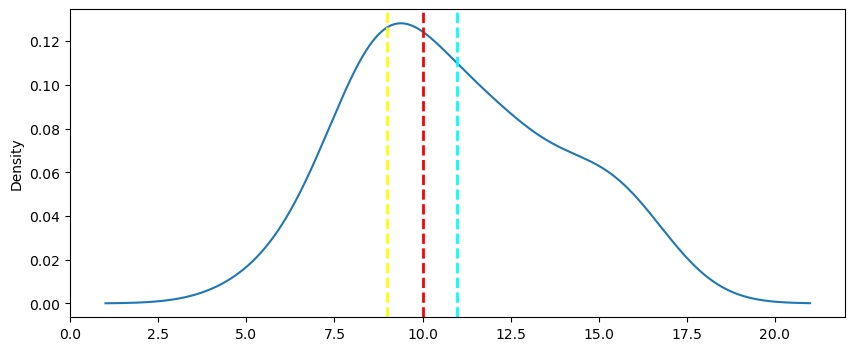

In [20]:
def show_density(var_data):
    fig= plt.figure(figsize=(10,4))

    var_data.plot.density()

    plt.axvline(x=var_data.mean(), color = 'cyan', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.median(), color = 'red', linestyle='dashed', linewidth = 2)
    plt.axvline(x=var_data.mode()[0], color = 'yellow', linestyle='dashed', linewidth = 2)

    plt.show()

show_density(col)

In [21]:
import math

mean = df_students.StudyHours.mean()
variance = 0

for hours in df_students.StudyHours:
    variance = variance + ((mean - hours)**2)

variance = variance/df_students.shape[0] #give the number of row

print("variance: ", variance)

std = math.sqrt(variance)

print("std: ", std)

variance:  11.607438016528924
std:  3.4069690366260925


In [22]:
for col_name in ['Grade', 'StudyHours']:
    col = df_students[col_name]
    rng = col.max() - col.min()
    var = col.var()
    std = col.std()
    print(f'\n{col_name}:\n - Range: {rng}\n - Variance: {var}\n - Std.dev: {std}')




Grade:
 - Range: 94.0
 - Variance: 472.53679653679666
 - Std.dev: 21.73791150356438

StudyHours:
 - Range: 15.0
 - Variance: 12.160173160173159
 - Std.dev: 3.487143983286775


In [23]:
# Calculate the stats first
m = df_students.Grade.mean()
s = df_students.Grade.std()

# Use the variables in your print statement
print(f"68% of grades will fall between {m - s} and {m + s}")

68% of grades will fall between 27.4439066782538 and 70.91972968538256


In [24]:
df_students.describe()

,StudyHours,Grade
count,22.000000,22.000000
mean,10.522727,49.181818
std,3.487144,21.737912
min,1.000000,3.000000
25%,9.000000,36.250000
50%,10.000000,49.500000
75%,12.375000,62.750000
max,16.000000,97.000000


In [25]:
df_sample = df_students[df_students.StudyHours>1]
print(df_sample)

         Name  StudyHours  Grade   Pass
0         Dan       10.00   50.0  False
1       Joann       11.50   50.0  False
2       Pedro        9.00   47.0  False
3       Rosie       16.00   97.0   True
4       Ethan        9.25   49.0  False
6    Frederic       11.50   53.0  False
7      Jimmie        9.00   42.0  False
8      Rhonda        8.50   26.0  False
9    Giovanni       14.50   74.0   True
10  Francesca       15.50   82.0   True
11      Rajab       13.75   62.0   True
12    Naiyana        9.00   37.0  False
13       Kian        8.00   15.0  False
14      Jenny       15.50   70.0   True
15     Jakeem        8.00   27.0  False
16     Helena        9.00   36.0  False
17      Ismat        6.00   35.0  False
18      Anila       10.00   48.0  False
19       Skye       12.00   52.0  False
20     Daniel       12.50   63.0   True
21      Aisha       12.00   64.0   True


<Axes: title={'center': 'StudyHours'}, xlabel='Pass'>

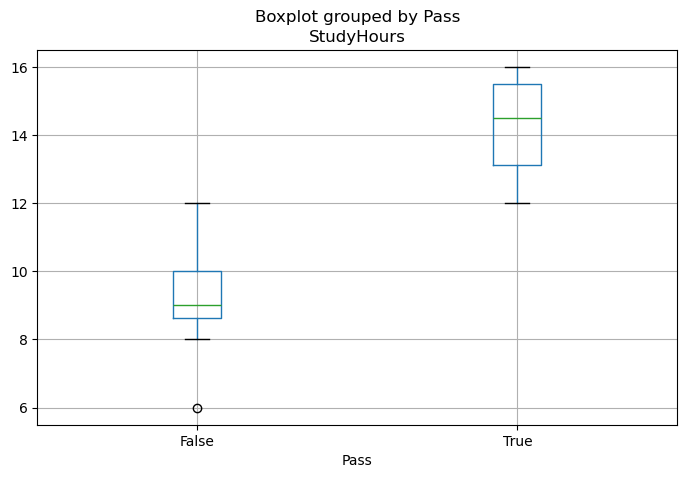

In [26]:
df_sample.boxplot(column = 'StudyHours', by='Pass', figsize=(8,5))

<Axes: xlabel='Name'>

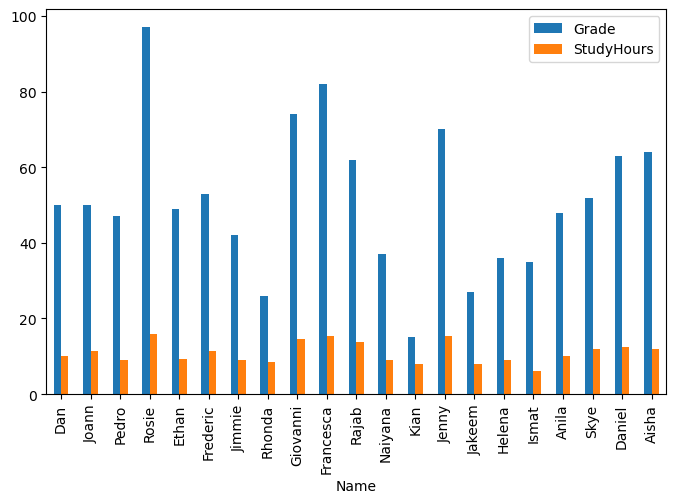

In [27]:
df_sample.plot(x='Name', y=['Grade', 'StudyHours'], kind='bar', figsize=(8,5))

<Axes: xlabel='Name'>

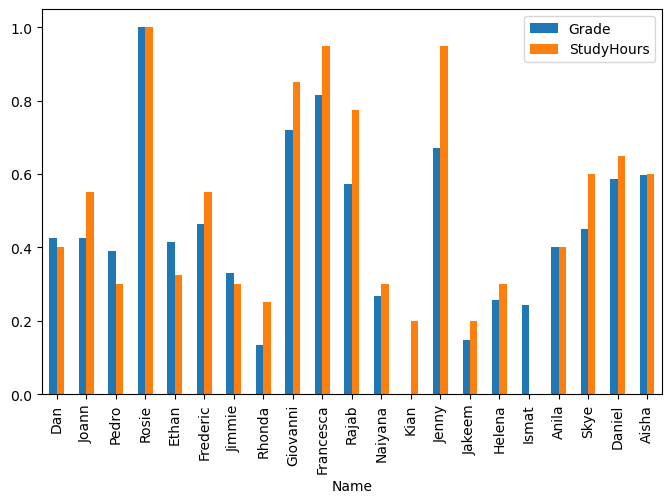

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalizes = df_sample[['Name', 'Grade', 'StudyHours']].copy()

df_normalizes[['Grade', 'StudyHours']] = scaler.fit_transform(df_normalizes[['Grade', 'StudyHours']])

df_normalizes.plot(x = 'Name', y =['Grade', 'StudyHours'], kind='bar', figsize=(8,5) )

In [29]:
print(df_normalizes.Grade.corr(df_normalizes.StudyHours)) #corr just mean corelation

0.9117666413789677


<Axes: title={'center': 'Study Time vs Grade'}, xlabel='StudyHours', ylabel='Grade'>

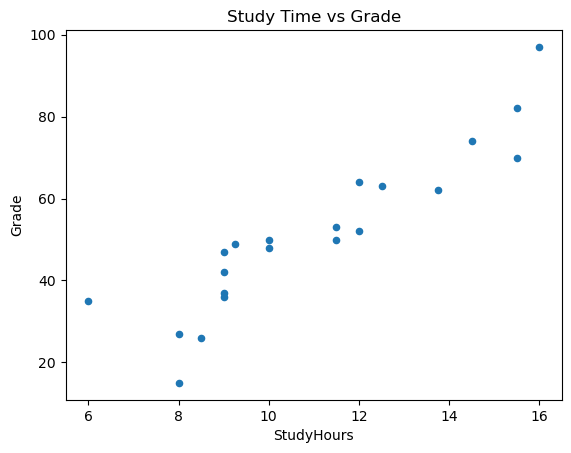

In [30]:
df_sample.plot.scatter(title='Study Time vs Grade', x='StudyHours', y='Grade')

In [31]:
y = mx + bs

f(x)

error = y - f(x) ** 2

NameError: name 'mx' is not defined

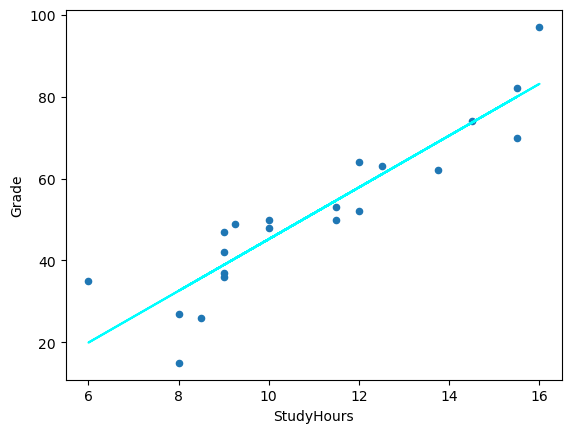

6.31342563379236 -17.91640993281615


In [ ]:
from scipy import stats

df_regression = df_sample[['Grade', 'StudyHours']].copy()

m, b, r, p, se=stats.linregress(df_regression['StudyHours'], df_regression['Grade'])

df_regression['fx'] = (m * df_regression['StudyHours']) + b

df_regression['error'] = df_regression['fx'] - df_regression['Grade']

df_regression.plot.scatter(x='StudyHours', y='Grade')

plt.plot(df_regression['StudyHours'], df_regression['fx'], color='cyan')

plt.show()

print(m, b)

In [32]:
def predict(x):
    m = 6.31342563379236
    b = - 17.91640993281615
    return m*x + b

prediction = predict(int(input("whats the study hour?")))

print(prediction)


550.2918971084963
